In [1]:
# -----------------------------------------------------------------------------
# ARTICLE 10 – PROPRIETE INTELLECTUELLE & LICENSE HEADER
# -----------------------------------------------------------------------------
# The present code is developed during a contest called « HI!CKATHON » organized
# at the request of HEC Paris and Institut Polytechnique de Paris, in the
# context of the Hi ! PARIS Center.
#
# License: LGPL v3 (Open Source)
# Authors: Gabin BIGARET, Antoine LOUVET, Rémi MALAPERT, Othmane NAMMOUS,
#          Valentin SENAUX et Tharushan UTHAYAKUMAR 
# -----------------------------------------------------------------------------


# 📊 Analyse Exploratoire des Données PISA - HI!CKATHON 2025

---

**Objectif**: Analyser en profondeur la structure, la qualité et les caractéristiques des données PISA (Programme International pour le Suivi des Acquis des élèves) pour préparer la modélisation prédictive de la réussite scolaire.

**Points clés de l'analyse**:
- 📁 Structure et dimensions du dataset
- 🔍 Taux de remplissage des colonnes
- 📉 Analyse des valeurs manquantes (spécifique PISA)
- 📊 Distribution des variables numériques et catégorielles
- 🔗 Corrélations entre variables
- 📋 Rapport de qualité des données

## 1️⃣ Import des Bibliothèques

In [2]:
# Manipulation de données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
import warnings
warnings.filterwarnings('ignore')

# Configuration de l'affichage pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Style des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Bibliothèques importées avec succès!")

✅ Bibliothèques importées avec succès!


## 2️⃣ Chargement et Inspection Initiale des Données

In [3]:
# Chargement des données X_train
print("📂 Chargement de X_train.csv...")
try:
    X_train = pd.read_csv('X_train.csv', low_memory=False)
    print(f"✅ X_train chargé: {X_train.shape[0]} lignes × {X_train.shape[1]} colonnes")
except Exception as e:
    print(f"❌ Erreur lors du chargement de X_train: {e}")
    X_train = None

# Chargement des données y_train
print("\n📂 Chargement de y_train.csv...")
try:
    y_train = pd.read_csv('y_train.csv', low_memory=False)
    print(f"✅ y_train chargé: {y_train.shape[0]} lignes × {y_train.shape[1]} colonnes")
except Exception as e:
    print(f"❌ Erreur lors du chargement de y_train: {e}")
    y_train = None

# Affichage des premières lignes
if X_train is not None:
    print("\n" + "="*80)
    print("📋 Aperçu des premières lignes de X_train:")
    print("="*80)
    display(X_train.head())

📂 Chargement de X_train.csv...
✅ X_train chargé: 1172086 lignes × 307 colonnes

📂 Chargement de y_train.csv...
✅ X_train chargé: 1172086 lignes × 307 colonnes

📂 Chargement de y_train.csv...
✅ y_train chargé: 1172086 lignes × 2 colonnes

📋 Aperçu des premières lignes de X_train:
✅ y_train chargé: 1172086 lignes × 2 colonnes

📋 Aperçu des premières lignes de X_train:


,Unnamed: 0,Year,CNT,CNTRYID,CNTSCHID,CNTSTUID,CYC,NatCen,STRATUM,SUBNATIO,OECD,ADMINMODE,LANGTEST_QQQ,LANGTEST_COG,LANGTEST_PAQ,Option_CT,Option_FL,Option_ICTQ,Option_WBQ,Option_PQ,Option_TQ,Option_UH,ST001D01T,ST003D02T,ST003D03T,ST004D01T,EFFORT1,EFFORT2,OCOD1,OCOD2,OCOD3,AGE,GRADE,ISCEDP,IMMIG,COBN_S,MISSSC,MATHEASE,WB153,ST253,ST311,WB165,IC171,ST038,IC180,ST255,ST350,ST034,FL162,PA195,ST330,FL169,ST230,ST331,ST354,PA042,ST305,ST258,PA167,IC176,ST352,IC173,PA188,ST283,ST256,WB154,WB166,FL150,ST266,IC174,ST005,ST021,IC182,FL164,FL160,ST267,ST338,ST351,ST342,ST355,FL166,PA183,ST007,FL170,WB168,WB163,IC184,ST348,ST226,ST336,WB160,FL167,PA166,ST250,ST268,IC177,PA196,IC183,ST275,IC172,IC175,ST340,ST296,ST270,ST289,ST353,ST349,ST301,PA186,WB164,PA197,ST290,ST062,ST254,ST345,ST322,IC170,PA006,ST347,ST343,ST307,ST160,ST168,ST161,ST153,ST188,PA009,PA182,PA004,ST059,ST150,PA158,WB155,WB162,ST127,EC162,ST104,PA003,ST125,ST163,ST297,ST006,ST263,PA162,ST164,ST008,ST152,EC031,WB177,ST183,EC012,ST223,ST177,ST102,PA041,EC163,PA008,PA177,ST175,ST273,EC153,ST212,PA154,PA156,PA007,PA159,ST300,ST036,PA018,ST208,ST165,PA175,ST167,ST211,WB176,ST158,WB178,IC014,ST213,ST327,ST251,ST260,PA160,ST095,PA033,ST146,ST098,ST100,ST097,ST113,PA002,PA032,IC001,ST008.1,ST006.1,PA008.1,ST011,reading_q1_average_score,reading_q2_average_score,reading_q3_average_score,reading_q4_average_score,reading_q5_average_score,reading_q6_average_score,reading_q7_average_score,reading_q8_average_score,reading_q9_average_score,reading_q10_average_score,reading_q11_average_score,reading_q12_average_score,reading_q13_average_score,reading_q14_average_score,reading_q15_average_score,math_q1_average_score,math_q2_average_score,math_q3_average_score,math_q4_average_score,math_q5_average_score,math_q6_average_score,math_q7_average_score,math_q8_average_score,math_q9_average_score,math_q10_average_score,math_q11_average_score,math_q12_average_score,math_q13_average_score,math_q14_average_score,math_q15_average_score,math_q16_average_score,math_q17_average_score,math_q18_average_score,math_q19_average_score,math_q20_average_score,math_q21_average_score,science_q1_average_score,science_q2_average_score,science_q3_average_score,science_q4_average_score,science_q5_average_score,science_q6_average_score,science_q7_average_score,science_q8_average_score,science_q9_average_score,science_q10_average_score,science_q11_average_score,science_q12_average_score,science_q13_average_score,science_q14_average_score,science_q15_average_score,science_q16_average_score,science_q17_average_score,science_q18_average_score,science_q19_average_score,reading_q1_total_timing,reading_q2_total_timing,reading_q3_total_timing,reading_q4_total_timing,reading_q5_total_timing,reading_q6_total_timing,reading_q7_total_timing,reading_q8_total_timing,reading_q9_total_timing,reading_q10_total_timing,reading_q11_total_timing,reading_q12_total_timing,reading_q13_total_timing,reading_q14_total_timing,reading_q15_total_timing,math_q1_total_timing,math_q2_total_timing,math_q3_total_timing,math_q4_total_timing,math_q5_total_timing,math_q6_total_timing,math_q7_total_timing,math_q8_total_timing,math_q9_total_timing,math_q10_total_timing,math_q11_total_timing,math_q12_total_timing,math_q13_total_timing,math_q14_total_timing,math_q15_total_timing,math_q16_total_timing,math_q17_total_timing,math_q18_total_timing,math_q19_total_timing,math_q20_total_timing,math_q21_total_timing,science_q1_total_timing,science_q2_total_timing,science_q3_total_timing,science_q4_total_timing,science_q5_total_timing,science_q6_total_timing,science_q7_total_timing,science_q8_total_timing,science_q9_total_timing,science_q10_total_timing,science_q11_total_timing,science_q12_total_timing,science_q13_total_timing,science_q14_total_timing,science_q15_total_timing,science_q16_total_timing,science_q17_total_timing,science_q18_total_timing,science_q19_total_timing
0,384002,2022,NLD,528.00,52800132.00,52801144.00,08MS,52800,NLD06,5280000,1.00,2.00,322.00,32

In [4]:
# Informations générales sur le dataset
if X_train is not None:
    print("="*80)
    print("📊 INFORMATIONS GÉNÉRALES SUR X_TRAIN")
    print("="*80)
    print(f"\n📐 Dimensions: {X_train.shape[0]:,} lignes × {X_train.shape[1]:,} colonnes")
    print(f"💾 Utilisation mémoire: {X_train.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print(f"\n🔢 Types de données:")
    print(X_train.dtypes.value_counts())
    
    # Statistiques de base
    print("\n" + "="*80)
    print("📈 STATISTIQUES DE BASE")
    print("="*80)
    X_train.info()

📊 INFORMATIONS GÉNÉRALES SUR X_TRAIN

📐 Dimensions: 1,172,086 lignes × 307 colonnes
💾 Utilisation mémoire: 2897.63 MB

🔢 Types de données:
float64    300
int64        4
object       3
Name: count, dtype: int64

📈 STATISTIQUES DE BASE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1172086 entries, 0 to 1172085
Columns: 307 entries, Unnamed: 0 to science_q19_total_timing
dtypes: float64(300), int64(4), object(3)
memory usage: 2.7+ GB
💾 Utilisation mémoire: 2897.63 MB

🔢 Types de données:
float64    300
int64        4
object       3
Name: count, dtype: int64

📈 STATISTIQUES DE BASE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1172086 entries, 0 to 1172085
Columns: 307 entries, Unnamed: 0 to science_q19_total_timing
dtypes: float64(300), int64(4), object(3)
memory usage: 2.7+ GB


## 3️⃣ Analyse Détaillée des Colonnes et Taux de Remplissage

In [5]:
# Création d'un DataFrame récapitulatif des colonnes
if X_train is not None:
    column_info = pd.DataFrame({
        'Colonne': X_train.columns,
        'Type': X_train.dtypes,
        'Valeurs_Non_Nulles': X_train.count(),
        'Valeurs_Nulles': X_train.isnull().sum(),
        'Pct_Manquant': (X_train.isnull().sum() / len(X_train) * 100).round(2),
        'Pct_Remplissage': ((1 - X_train.isnull().sum() / len(X_train)) * 100).round(2),
        'Valeurs_Uniques': X_train.nunique(),
        'Exemple_Valeur': X_train.iloc[0]
    })
    
    # Tri par pourcentage de valeurs manquantes (décroissant)
    column_info = column_info.sort_values('Pct_Manquant', ascending=False).reset_index(drop=True)
    
    print("="*80)
    print("📊 TABLEAU RÉCAPITULATIF DES COLONNES")
    print("="*80)
    display(column_info.head(30))
    
    # Statistiques globales sur les valeurs manquantes
    print("\n" + "="*80)
    print("📉 STATISTIQUES GLOBALES SUR LES VALEURS MANQUANTES")
    print("="*80)
    print(f"✓ Colonnes totales: {len(column_info)}")
    print(f"✓ Colonnes complètes (0% manquant): {(column_info['Pct_Manquant'] == 0).sum()}")
    print(f"✓ Colonnes avec <10% manquant: {(column_info['Pct_Manquant'] < 10).sum()}")
    print(f"✓ Colonnes avec 10-50% manquant: {((column_info['Pct_Manquant'] >= 10) & (column_info['Pct_Manquant'] < 50)).sum()}")
    print(f"⚠ Colonnes avec >50% manquant: {(column_info['Pct_Manquant'] >= 50).sum()}")
    print(f"🔴 Colonnes entièrement vides (100% manquant): {(column_info['Pct_Manquant'] == 100).sum()}")

📊 TABLEAU RÉCAPITULATIF DES COLONNES


,Colonne,Type,Valeurs_Non_Nulles,Valeurs_Nulles,Pct_Manquant,Pct_Remplissage,Valeurs_Uniques,Exemple_Valeur
0,science_q19_total_timing,float64,1,1172085,100.00,0.00,1,NaN
1,math_q21_average_score,float64,0,1172086,100.00,0.00,0,NaN
2,reading_q13_total_timing,float64,41,1172045,100.00,0.00,41,NaN
3,science_q19_average_score,float64,1,1172085,100.00,0.00,1,NaN
4,science_q18_average_score,float64,1,1172085,100.00,0.00,1,NaN
5,science_q17_average_score,float64,1,1172085,100.00,0.00,1,NaN
6,science_q15_average_score,float64,1,1172085,100.00,0.00,1,NaN
7,science_q14_average_score,float64,1,1172085,100.00,0.00,1,NaN
8,science_q13_average_score,float64,1,1172085,100.00,0.00,1,NaN
9,math_q20_average_score,float64,0,1172086,100.00,0.00,0,NaN



📉 STATISTIQUES GLOBALES SUR LES VALEURS MANQUANTES
✓ Colonnes totales: 307
✓ Colonnes complètes (0% manquant): 15
✓ Colonnes avec <10% manquant: 19
✓ Colonnes avec 10-50% manquant: 82
⚠ Colonnes avec >50% manquant: 206
🔴 Colonnes entièrement vides (100% manquant): 31


## 4️⃣ Visualisation des Valeurs Manquantes

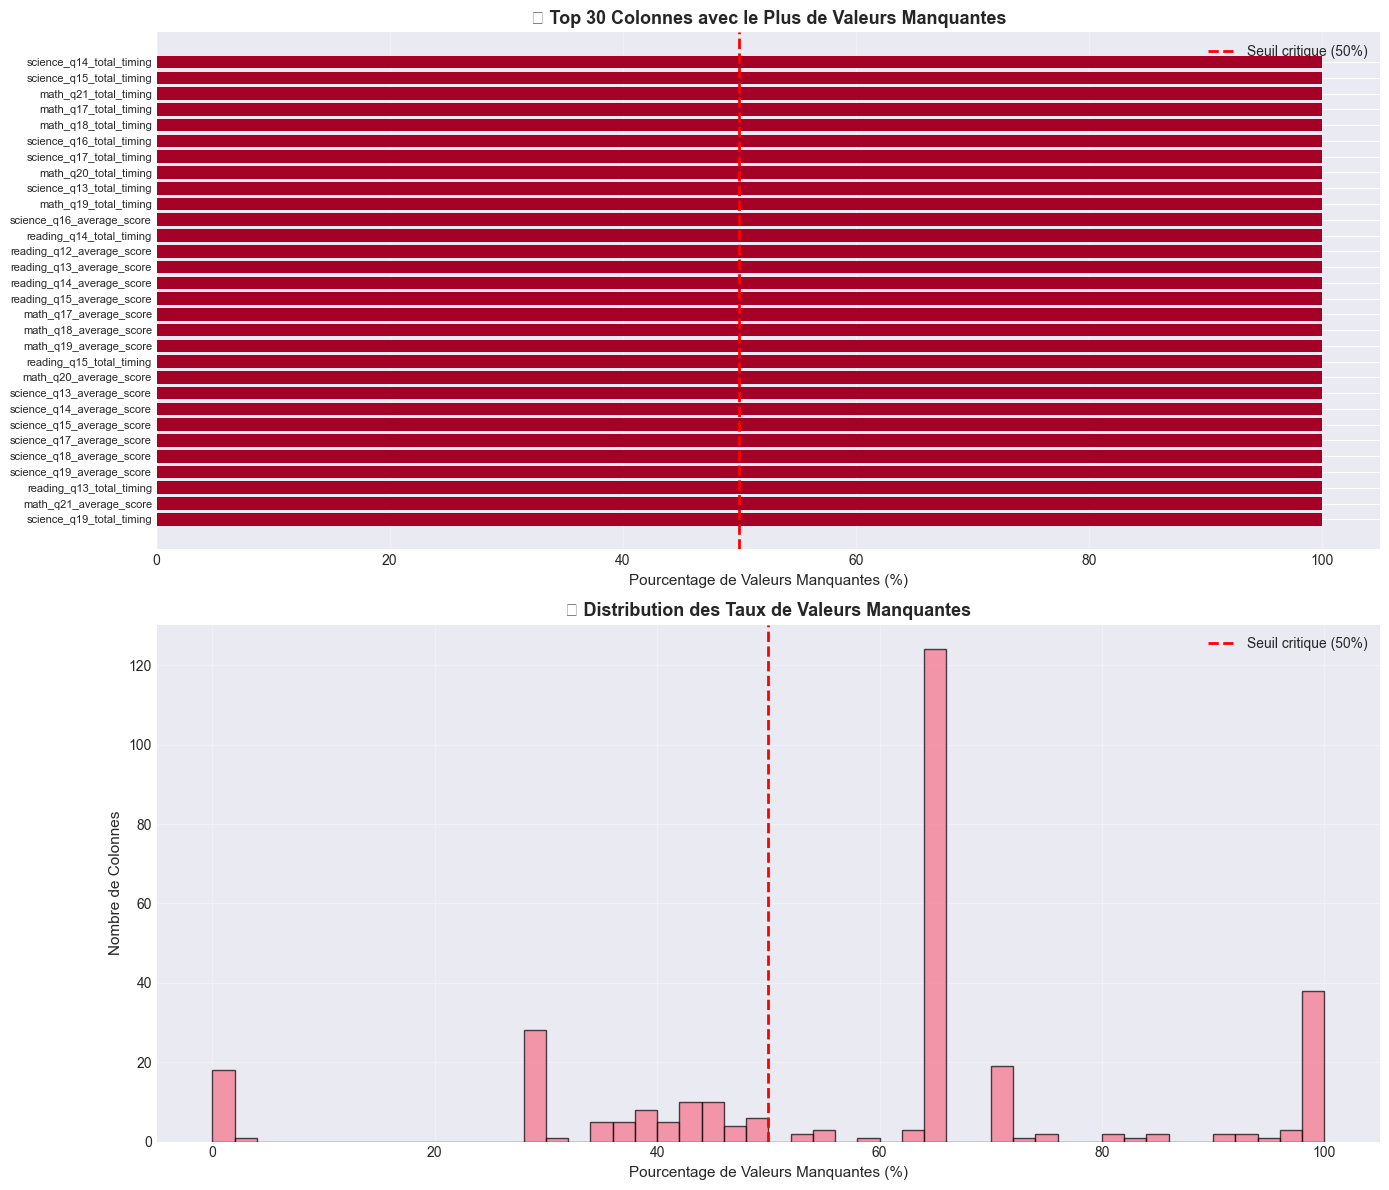

In [6]:
# Graphique 1: Top 30 colonnes avec le plus de valeurs manquantes
if X_train is not None:
    fig, axes = plt.subplots(2, 1, figsize=(14, 12))
    
    # Top 30 colonnes avec valeurs manquantes
    top_missing = column_info[column_info['Pct_Manquant'] > 0].head(30)
    
    axes[0].barh(range(len(top_missing)), top_missing['Pct_Manquant'], 
                 color=plt.cm.RdYlGn_r(top_missing['Pct_Manquant']/100))
    axes[0].set_yticks(range(len(top_missing)))
    axes[0].set_yticklabels(top_missing['Colonne'], fontsize=8)
    axes[0].set_xlabel('Pourcentage de Valeurs Manquantes (%)', fontsize=11)
    axes[0].set_title('🔴 Top 30 Colonnes avec le Plus de Valeurs Manquantes', fontsize=13, fontweight='bold')
    axes[0].axvline(x=50, color='red', linestyle='--', linewidth=2, label='Seuil critique (50%)')
    axes[0].legend()
    axes[0].grid(axis='x', alpha=0.3)
    
    # Distribution des taux de valeurs manquantes
    axes[1].hist(column_info['Pct_Manquant'], bins=50, edgecolor='black', alpha=0.7)
    axes[1].axvline(x=50, color='red', linestyle='--', linewidth=2, label='Seuil critique (50%)')
    axes[1].set_xlabel('Pourcentage de Valeurs Manquantes (%)', fontsize=11)
    axes[1].set_ylabel('Nombre de Colonnes', fontsize=11)
    axes[1].set_title('📊 Distribution des Taux de Valeurs Manquantes', fontsize=13, fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

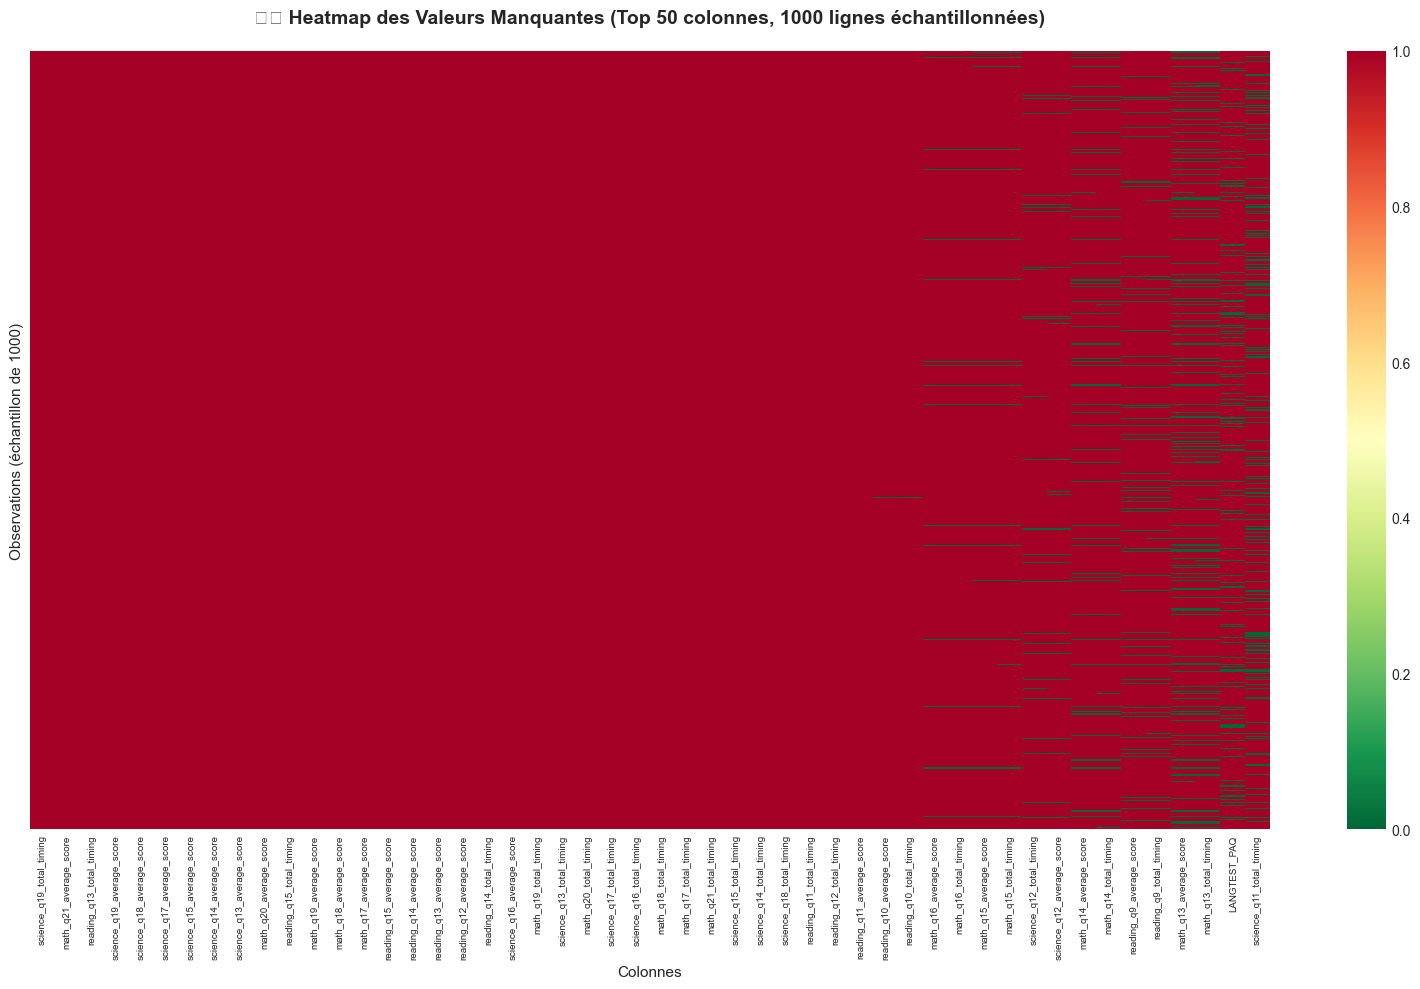

In [7]:
# Graphique 2: Heatmap des valeurs manquantes (échantillon de colonnes)
if X_train is not None:
    # Sélection d'un échantillon de colonnes pour la visualisation (top 50 + 50 aléatoires)
    cols_with_missing = column_info[column_info['Pct_Manquant'] > 0]['Colonne'].head(50).tolist()
    
    if len(cols_with_missing) > 0:
        # Échantillon de lignes pour la performance
        sample_size = min(1000, len(X_train))
        sample_idx = np.random.choice(X_train.index, sample_size, replace=False)
        
        plt.figure(figsize=(16, 10))
        sns.heatmap(X_train.loc[sample_idx, cols_with_missing].isnull(), 
                    cmap='RdYlGn_r', cbar=True, yticklabels=False)
        plt.title(f'🗺️ Heatmap des Valeurs Manquantes (Top 50 colonnes, {sample_size} lignes échantillonnées)', 
                  fontsize=14, fontweight='bold', pad=20)
        plt.xlabel('Colonnes', fontsize=11)
        plt.ylabel(f'Observations (échantillon de {sample_size})', fontsize=11)
        plt.xticks(rotation=90, fontsize=7)
        plt.tight_layout()
        plt.show()
    else:
        print("✅ Aucune valeur manquante détectée dans le dataset!")

## 5️⃣ Distribution des Types de Données

📊 DISTRIBUTION DES TYPES DE DONNÉES


,Type,Nombre
0,Numériques,304
1,Catégorielles,3
2,Date/Temps,0
3,Autres,0


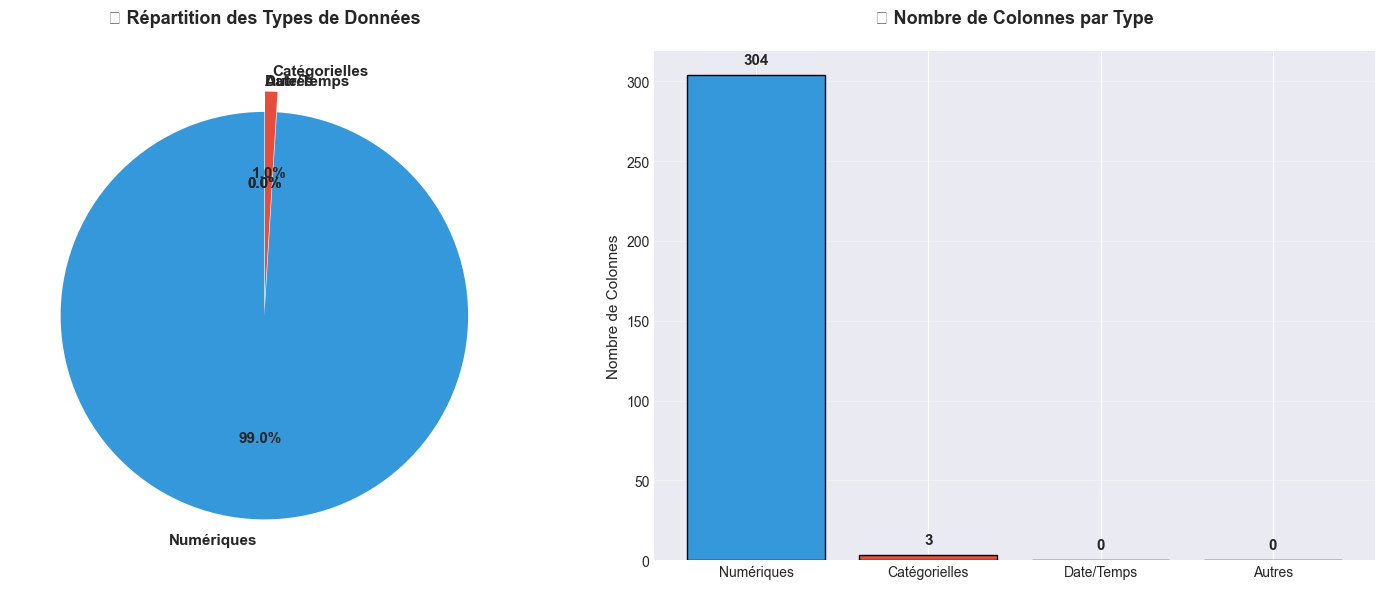


✓ Variables numériques: 304
✓ Variables catégorielles: 3
✓ Variables date/temps: 0


In [8]:
# Analyse des types de données
if X_train is not None:
    # Catégorisation des types
    numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
    categorical_cols = X_train.select_dtypes(include=['object', 'category', 'bool']).columns
    datetime_cols = X_train.select_dtypes(include=['datetime64']).columns
    
    type_distribution = pd.DataFrame({
        'Type': ['Numériques', 'Catégorielles', 'Date/Temps', 'Autres'],
        'Nombre': [len(numeric_cols), len(categorical_cols), len(datetime_cols), 
                   len(X_train.columns) - len(numeric_cols) - len(categorical_cols) - len(datetime_cols)]
    })
    
    print("="*80)
    print("📊 DISTRIBUTION DES TYPES DE DONNÉES")
    print("="*80)
    display(type_distribution)
    
    # Visualisation
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Pie chart
    colors = ['#3498db', '#e74c3c', '#f39c12', '#95a5a6']
    explode = (0.05, 0.05, 0, 0)
    
    axes[0].pie(type_distribution['Nombre'], labels=type_distribution['Type'], 
                autopct='%1.1f%%', startangle=90, colors=colors, explode=explode,
                textprops={'fontsize': 11, 'weight': 'bold'})
    axes[0].set_title('📊 Répartition des Types de Données', fontsize=13, fontweight='bold', pad=20)
    
    # Bar chart
    axes[1].bar(type_distribution['Type'], type_distribution['Nombre'], color=colors, edgecolor='black')
    axes[1].set_ylabel('Nombre de Colonnes', fontsize=11)
    axes[1].set_title('📈 Nombre de Colonnes par Type', fontsize=13, fontweight='bold', pad=20)
    axes[1].grid(axis='y', alpha=0.3)
    
    # Annotation des valeurs sur les barres
    for i, v in enumerate(type_distribution['Nombre']):
        axes[1].text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ Variables numériques: {len(numeric_cols)}")
    print(f"✓ Variables catégorielles: {len(categorical_cols)}")
    print(f"✓ Variables date/temps: {len(datetime_cols)}")

## 6️⃣ Analyse Statistique des Variables Numériques

In [9]:
# Statistiques descriptives des variables numériques
if X_train is not None and len(numeric_cols) > 0:
    print("="*80)
    print("📈 STATISTIQUES DESCRIPTIVES DES VARIABLES NUMÉRIQUES")
    print("="*80)
    
    numeric_stats = X_train[numeric_cols].describe().T
    numeric_stats['missing_pct'] = (X_train[numeric_cols].isnull().sum() / len(X_train) * 100).round(2)
    numeric_stats = numeric_stats[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'missing_pct']]
    numeric_stats.columns = ['Non-Null', 'Moyenne', 'Écart-type', 'Min', 'Q1', 'Médiane', 'Q3', 'Max', '% Manquant']
    
    display(numeric_stats.head(20))
    
    print(f"\n✓ Total de variables numériques: {len(numeric_cols)}")

📈 STATISTIQUES DESCRIPTIVES DES VARIABLES NUMÉRIQUES


,Non-Null,Moyenne,Écart-type,Min,Q1,Médiane,Q3,Max,% Manquant
Unnamed: 0,1172086.00,878812.70,507534.02,0.00,439061.25,878783.50,1318403.75,1758128.00,0.00
Year,1172086.00,2018.52,2.84,2015.00,2015.00,2018.00,2022.00,2022.00,0.00
CNTRYID,1172086.00,449.44,272.92,8.00,203.00,411.00,703.00,983.00,0.00
CNTSCHID,1172086.00,44944330.55,27292019.21,800001.00,20300359.00,41100179.00,70300259.00,98300806.00,0.00
CNTSTUID,1172086.00,44929259.06,27260770.31,800001.00,20309659.25,41104022.50,70305895.75,98329122.00,0.00
NatCen,1172086.00,43212.44,25830.40,800.00,19100.00,41000.00,70200.00,86000.00,0.00
SUBNATIO,1172086.00,4437437.12,2655082.53,80000.00,2030000.00,4110000.00,7030000.00,9830000.00,0.00
OECD,1172086.00,0.52,0.54,0.00,0.00,1.00,1.00,2.00,0.00
ADMINMODE,1172086.00,1.91,0.28,1.00,2.00,2.00,2.00,2.00,0.00
LANGTEST_QQQ,1156728.00,313.60,155.61,113.00,156.00,313.00,442.00,998.00,1.31



✓ Total de variables numériques: 304


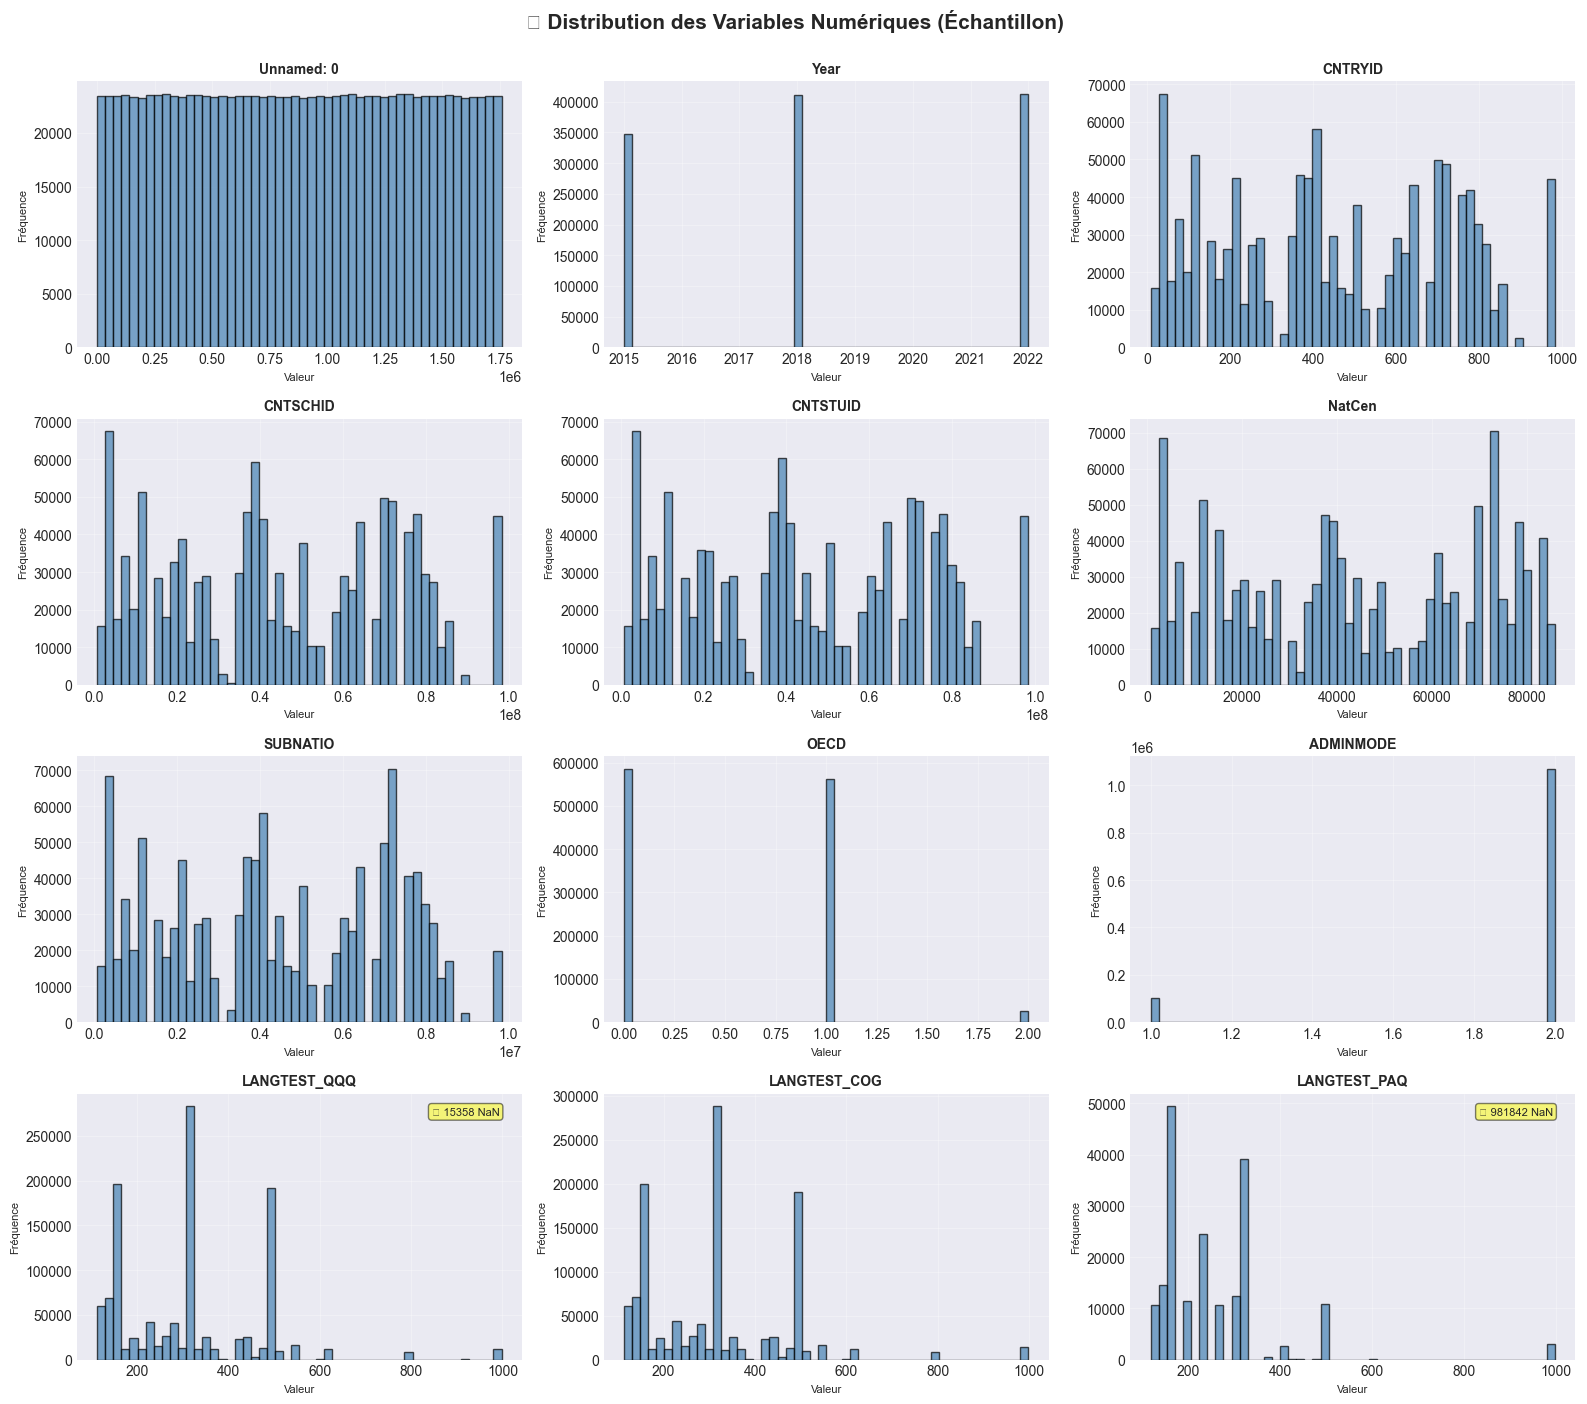

In [10]:
# Visualisation des distributions (échantillon de 12 variables numériques)
if X_train is not None and len(numeric_cols) > 0:
    # Sélection d'un échantillon représentatif
    sample_numeric = numeric_cols[:min(12, len(numeric_cols))]
    
    fig, axes = plt.subplots(4, 3, figsize=(16, 14))
    axes = axes.flatten()
    
    for idx, col in enumerate(sample_numeric):
        if idx < len(axes):
            # Histogramme avec KDE
            axes[idx].hist(X_train[col].dropna(), bins=50, edgecolor='black', alpha=0.7, color='steelblue')
            axes[idx].set_title(f'{col}', fontsize=10, fontweight='bold')
            axes[idx].set_xlabel('Valeur', fontsize=8)
            axes[idx].set_ylabel('Fréquence', fontsize=8)
            axes[idx].grid(alpha=0.3)
            
            # Annotation du nombre de valeurs manquantes
            missing = X_train[col].isnull().sum()
            if missing > 0:
                axes[idx].text(0.95, 0.95, f'⚠ {missing} NaN', 
                             transform=axes[idx].transAxes,
                             ha='right', va='top', 
                             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5),
                             fontsize=8)
    
    # Cacher les axes non utilisés
    for idx in range(len(sample_numeric), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('📊 Distribution des Variables Numériques (Échantillon)', 
                 fontsize=15, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

## 7️⃣ Analyse des Variables Catégorielles

In [11]:
# Analyse des variables catégorielles
if X_train is not None and len(categorical_cols) > 0:
    print("="*80)
    print("🏷️ ANALYSE DES VARIABLES CATÉGORIELLES")
    print("="*80)
    
    cat_summary = pd.DataFrame({
        'Variable': categorical_cols,
        'Valeurs_Uniques': [X_train[col].nunique() for col in categorical_cols],
        'Mode': [X_train[col].mode()[0] if len(X_train[col].mode()) > 0 else None for col in categorical_cols],
        'Fréquence_Mode': [X_train[col].value_counts().iloc[0] if len(X_train[col].value_counts()) > 0 else 0 for col in categorical_cols],
        'Pct_Mode': [(X_train[col].value_counts().iloc[0] / X_train[col].count() * 100).round(2) if len(X_train[col].value_counts()) > 0 else 0 for col in categorical_cols],
        'Valeurs_Manquantes': [X_train[col].isnull().sum() for col in categorical_cols]
    })
    
    cat_summary = cat_summary.sort_values('Valeurs_Uniques', ascending=False).reset_index(drop=True)
    display(cat_summary.head(20))
    
    print(f"\n✓ Total de variables catégorielles: {len(categorical_cols)}")
    print(f"✓ Variables binaires (2 catégories): {(cat_summary['Valeurs_Uniques'] == 2).sum()}")
    print(f"✓ Variables multi-catégories (>10): {(cat_summary['Valeurs_Uniques'] > 10).sum()}")

🏷️ ANALYSE DES VARIABLES CATÉGORIELLES


,Variable,Valeurs_Uniques,Mode,Fréquence_Mode,Pct_Mode,Valeurs_Manquantes
0,STRATUM,2731,ITA9797,15502,1.32,0
1,CNT,98,ESP,48846,4.17,0
2,CYC,3,08MS,412647,35.21,0



✓ Total de variables catégorielles: 3
✓ Variables binaires (2 catégories): 0
✓ Variables multi-catégories (>10): 2


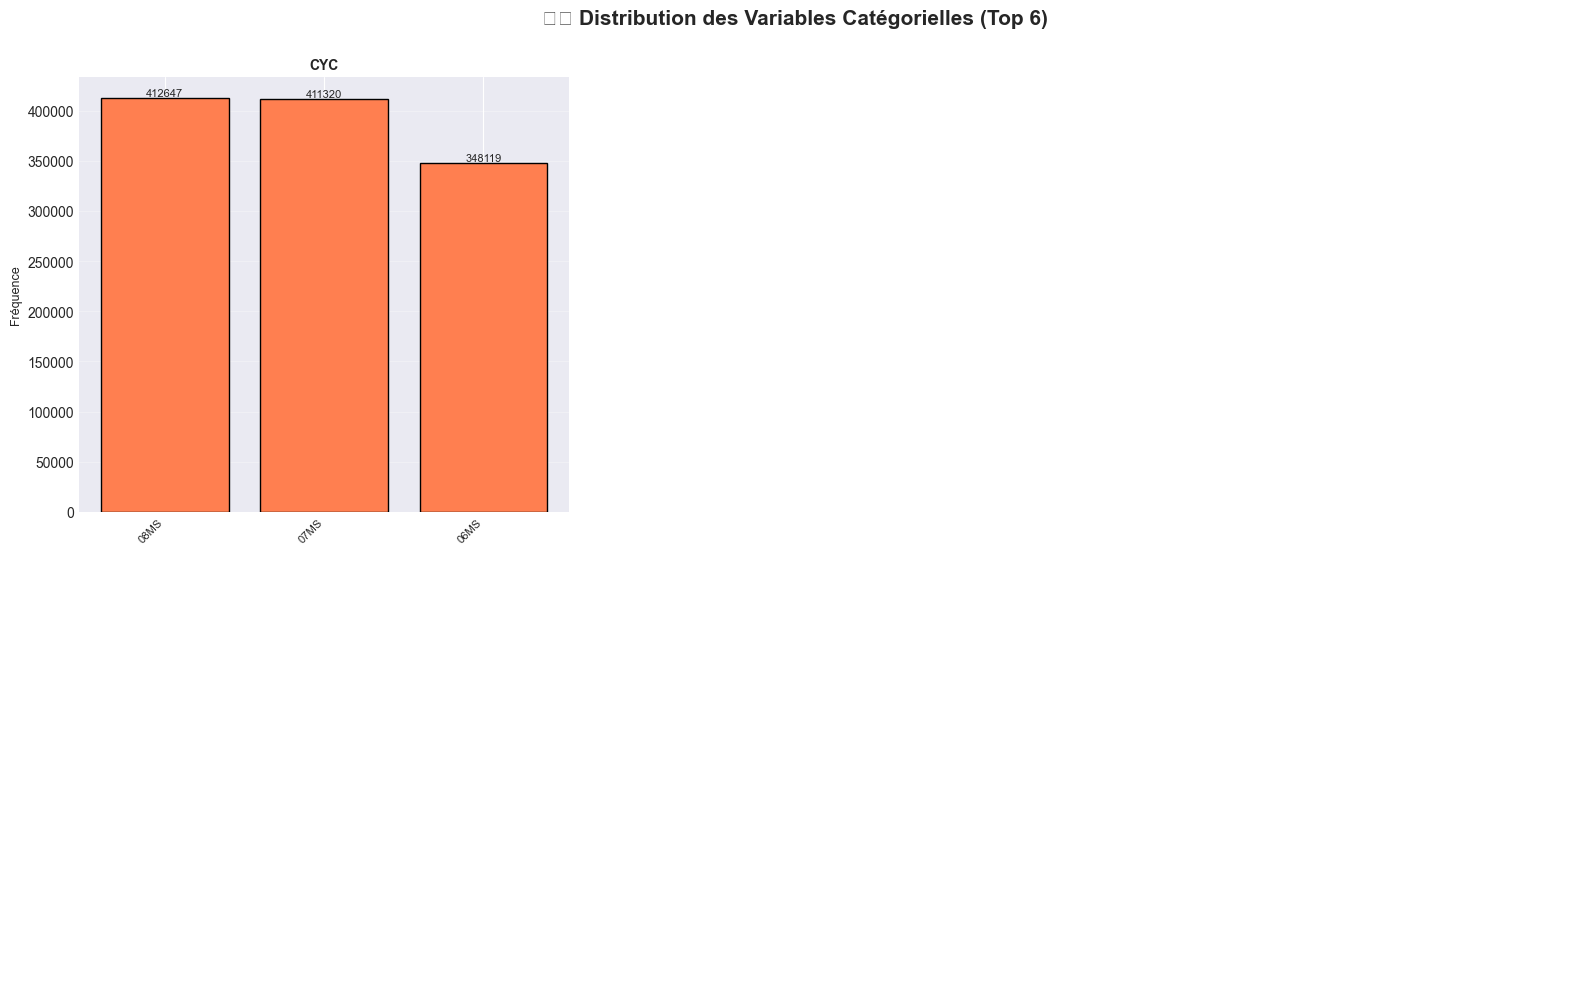

In [12]:
# Visualisation des principales variables catégorielles (top 6 avec peu de catégories)
if X_train is not None and len(categorical_cols) > 0:
    # Sélectionner les variables avec moins de 10 catégories pour la visualisation
    viz_cats = [col for col in categorical_cols if X_train[col].nunique() <= 10 and X_train[col].nunique() > 1][:6]
    
    if len(viz_cats) > 0:
        fig, axes = plt.subplots(2, 3, figsize=(16, 10))
        axes = axes.flatten()
        
        for idx, col in enumerate(viz_cats):
            if idx < len(axes):
                value_counts = X_train[col].value_counts().head(10)
                axes[idx].bar(range(len(value_counts)), value_counts.values, color='coral', edgecolor='black')
                axes[idx].set_xticks(range(len(value_counts)))
                axes[idx].set_xticklabels([str(x)[:15] for x in value_counts.index], rotation=45, ha='right', fontsize=8)
                axes[idx].set_title(f'{col}', fontsize=10, fontweight='bold')
                axes[idx].set_ylabel('Fréquence', fontsize=9)
                axes[idx].grid(axis='y', alpha=0.3)
                
                # Annotation des valeurs
                for i, v in enumerate(value_counts.values):
                    axes[idx].text(i, v, str(v), ha='center', va='bottom', fontsize=8)
        
        # Cacher les axes non utilisés
        for idx in range(len(viz_cats), len(axes)):
            axes[idx].axis('off')
        
        plt.suptitle('🏷️ Distribution des Variables Catégorielles (Top 6)', 
                     fontsize=15, fontweight='bold', y=1.00)
        plt.tight_layout()
        plt.show()
    else:
        print("⚠ Aucune variable catégorielle adaptée à la visualisation trouvée.")

## 8️⃣ Matrice de Corrélation des Variables Numériques

🔗 MATRICE DE CORRÉLATION DES VARIABLES NUMÉRIQUES


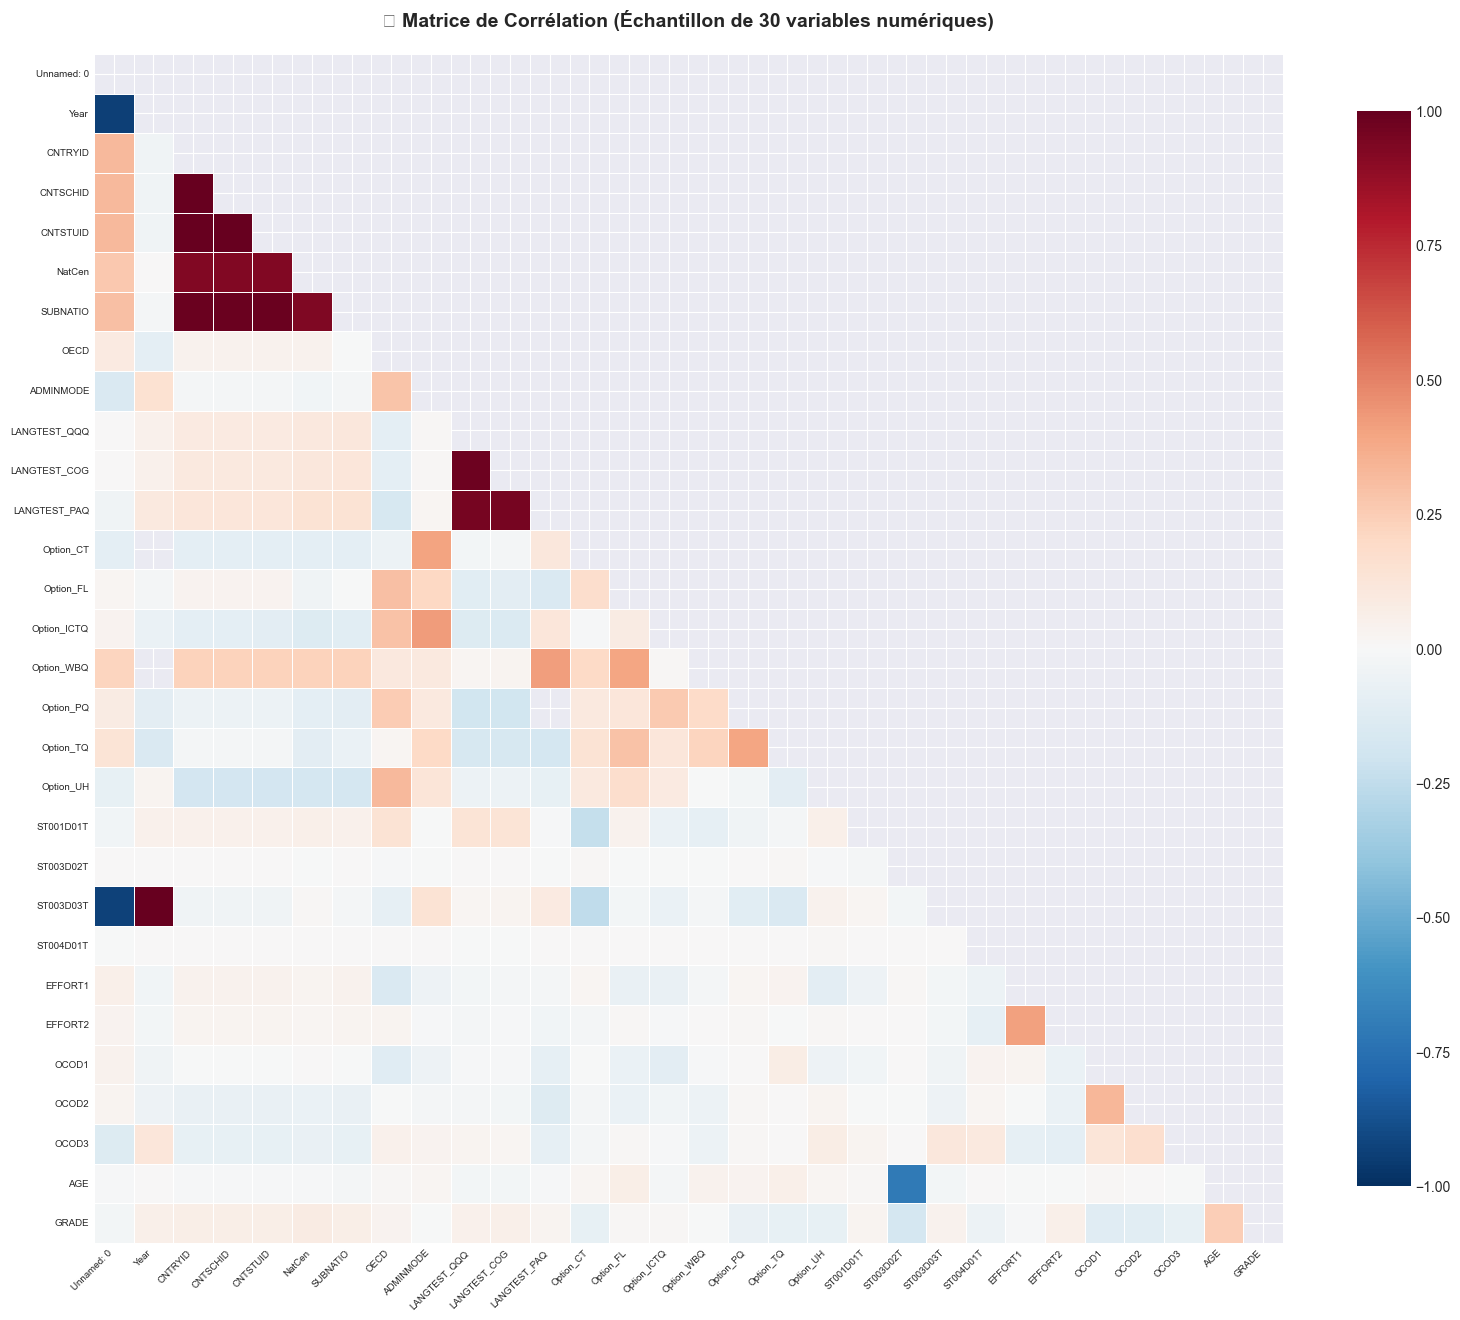


⚡ CORRÉLATIONS FORTES (|r| > 0.7)


,Variable_1,Variable_2,Corrélation
3,CNTRYID,CNTSCHID,1.00
4,CNTRYID,CNTSTUID,1.00
7,CNTSCHID,CNTSTUID,1.00
2,Year,ST003D03T,1.00
6,CNTRYID,SUBNATIO,0.99
9,CNTSCHID,SUBNATIO,0.99
11,CNTSTUID,SUBNATIO,0.99
13,LANGTEST_QQQ,LANGTEST_COG,0.98
14,LANGTEST_QQQ,LANGTEST_PAQ,0.96
15,LANGTEST_COG,LANGTEST_PAQ,0.96



✓ 17 paires de variables fortement corrélées identifiées


In [13]:
# Calcul de la matrice de corrélation (échantillon de variables)
if X_train is not None and len(numeric_cols) > 0:
    print("="*80)
    print("🔗 MATRICE DE CORRÉLATION DES VARIABLES NUMÉRIQUES")
    print("="*80)
    
    # Sélection d'un échantillon pour la performance (max 30 variables)
    sample_corr_cols = numeric_cols[:min(30, len(numeric_cols))]
    
    # Calcul de la corrélation
    correlation_matrix = X_train[sample_corr_cols].corr()
    
    # Visualisation
    plt.figure(figsize=(16, 14))
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    sns.heatmap(correlation_matrix, mask=mask, annot=False, cmap='RdBu_r', 
                center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
                vmin=-1, vmax=1)
    plt.title('🔗 Matrice de Corrélation (Échantillon de 30 variables numériques)', 
              fontsize=14, fontweight='bold', pad=20)
    plt.xticks(rotation=45, ha='right', fontsize=7)
    plt.yticks(fontsize=7)
    plt.tight_layout()
    plt.show()
    
    # Identification des corrélations fortes
    print("\n" + "="*80)
    print("⚡ CORRÉLATIONS FORTES (|r| > 0.7)")
    print("="*80)
    
    # Extraction des paires avec corrélation forte
    high_corr = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            if abs(correlation_matrix.iloc[i, j]) > 0.7:
                high_corr.append({
                    'Variable_1': correlation_matrix.columns[i],
                    'Variable_2': correlation_matrix.columns[j],
                    'Corrélation': correlation_matrix.iloc[i, j].round(3)
                })
    
    if len(high_corr) > 0:
        high_corr_df = pd.DataFrame(high_corr).sort_values('Corrélation', key=abs, ascending=False)
        display(high_corr_df.head(20))
        print(f"\n✓ {len(high_corr)} paires de variables fortement corrélées identifiées")
    else:
        print("✓ Aucune corrélation forte (|r| > 0.7) détectée dans l'échantillon")

## 9️⃣ Détection des Codes Manquants Spécifiques PISA

🔍 DÉTECTION DES CODES MANQUANTS PISA (9999, 999, 99, 'r', 'n', 'a')


,Colonne,Total_Codes_PISA,Pct_Total,Codes_Détectés
4,OCOD3,155543,13.27,9999:155543
3,OCOD2,100331,8.56,9999:100331
2,OCOD1,83004,7.08,9999:83004
17,math_q7_total_timing,6,0.00,"9999:2, 99999:4"
6,reading_q3_total_timing,5,0.00,"9999:2, 999:2, 99999:1"
7,reading_q4_total_timing,5,0.00,"9999:1, 999:1, 99999:3"
8,reading_q5_total_timing,5,0.00,"9999:1, 999:2, 99999:2"
19,math_q9_total_timing,5,0.00,"9999:2, 99999:3"
16,math_q6_total_timing,4,0.00,"9999:1, 999:1, 99999:2"
27,science_q6_total_timing,4,0.00,"9999:1, 999:2, 99999:1"



✓ 32 colonnes contiennent des codes manquants PISA
✓ Total de codes manquants détectés: 338,965


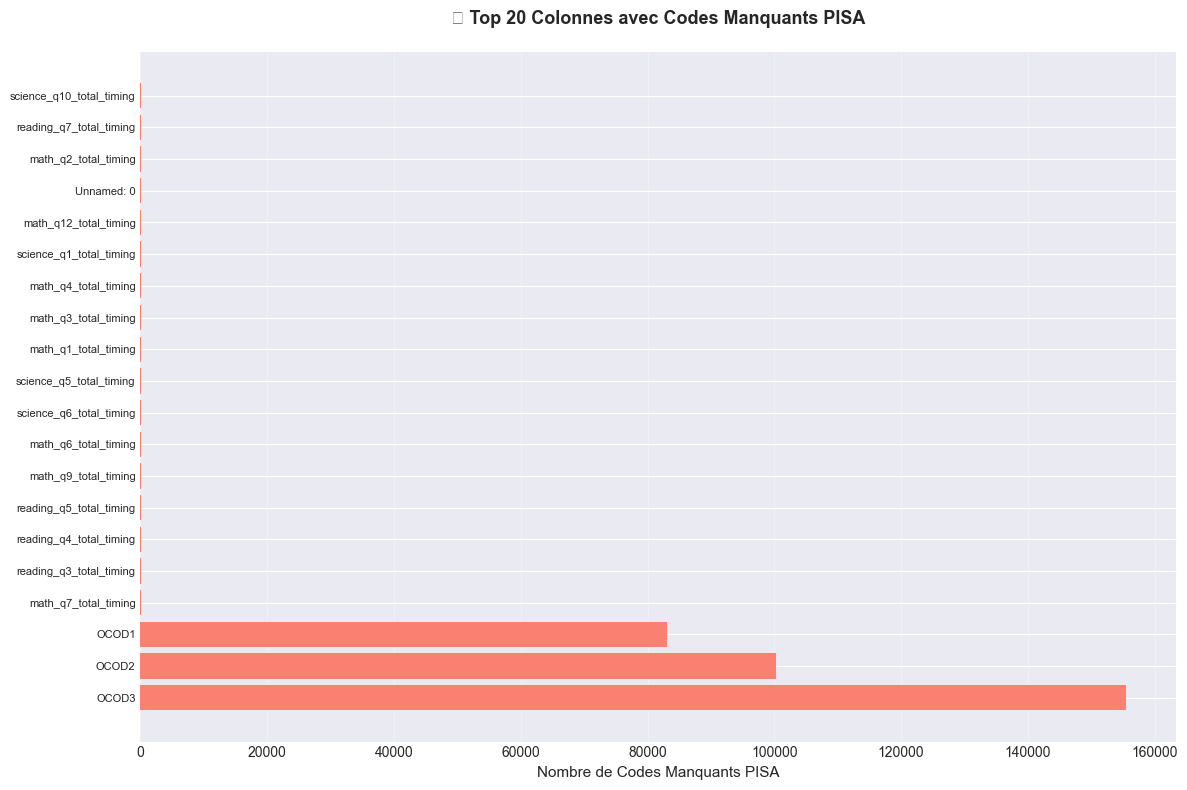

In [14]:
# Détection des codes de valeurs manquantes spécifiques à PISA
if X_train is not None:
    print("="*80)
    print("🔍 DÉTECTION DES CODES MANQUANTS PISA (9999, 999, 99, 'r', 'n', 'a')")
    print("="*80)
    
    missing_codes = [9999, 999, 99, 99999, 'r', 'n', 'a']
    pisa_missing_summary = []
    
    for col in X_train.columns:
        code_counts = {}
        total_codes = 0
        
        for code in missing_codes:
            try:
                count = (X_train[col] == code).sum()
                if count > 0:
                    code_counts[code] = count
                    total_codes += count
            except:
                pass
        
        if total_codes > 0:
            pisa_missing_summary.append({
                'Colonne': col,
                'Total_Codes_PISA': total_codes,
                'Pct_Total': (total_codes / len(X_train) * 100).round(2),
                'Codes_Détectés': ', '.join([f"{k}:{v}" for k, v in code_counts.items()])
            })
    
    if len(pisa_missing_summary) > 0:
        pisa_missing_df = pd.DataFrame(pisa_missing_summary).sort_values('Total_Codes_PISA', ascending=False)
        display(pisa_missing_df.head(30))
        
        print(f"\n✓ {len(pisa_missing_df)} colonnes contiennent des codes manquants PISA")
        print(f"✓ Total de codes manquants détectés: {pisa_missing_df['Total_Codes_PISA'].sum():,}")
        
        # Visualisation
        top_pisa_missing = pisa_missing_df.head(20)
        plt.figure(figsize=(12, 8))
        plt.barh(range(len(top_pisa_missing)), top_pisa_missing['Total_Codes_PISA'], color='salmon')
        plt.yticks(range(len(top_pisa_missing)), top_pisa_missing['Colonne'], fontsize=8)
        plt.xlabel('Nombre de Codes Manquants PISA', fontsize=11)
        plt.title('🔍 Top 20 Colonnes avec Codes Manquants PISA', fontsize=13, fontweight='bold', pad=20)
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("✅ Aucun code manquant PISA détecté dans le dataset")

## 🔟 Analyse de la Variable Cible (y_train)

🎯 ANALYSE DE LA VARIABLE CIBLE
Colonnes dans y_train: ['Unnamed: 0', 'MathScore']


📊 Analyse de: Unnamed: 0

Nombre de valeurs: 1172086
Valeurs manquantes: 0 (0.00%)
Valeurs uniques: 1172086

📈 Statistiques descriptives:
count   1172086.00
mean     878812.70
std      507534.02
min           0.00
25%      439061.25
50%      878783.50
75%     1318403.75
max     1758128.00
Name: Unnamed: 0, dtype: float64


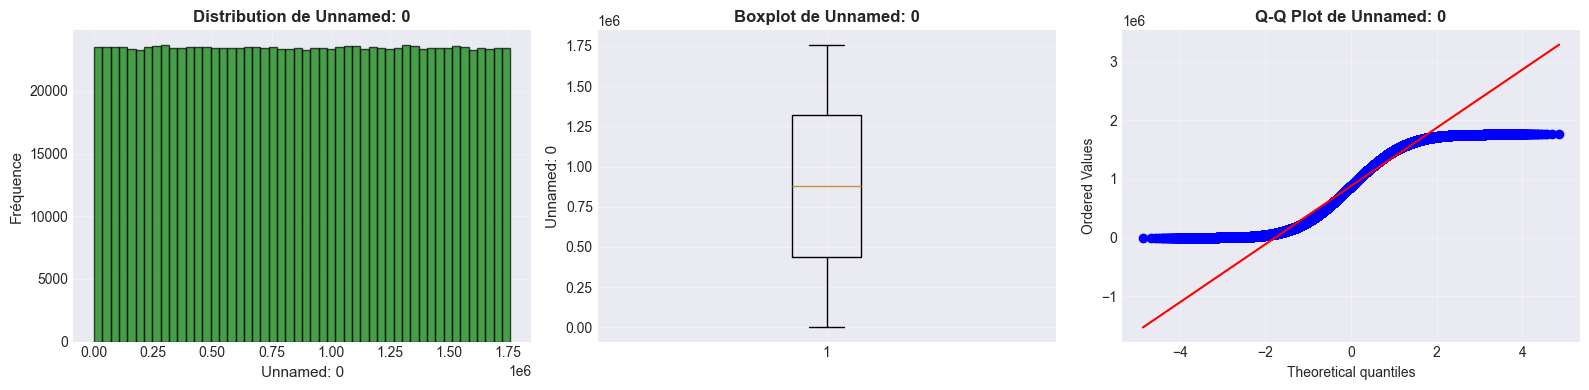


📊 Analyse de: MathScore

Nombre de valeurs: 1172086
Valeurs manquantes: 0 (0.00%)
Valeurs uniques: 13933

📈 Statistiques descriptives:
count   1172086.00
mean        100.00
std         122.18
min           0.00
25%           0.00
50%          66.05
75%         152.81
max         814.97
Name: MathScore, dtype: float64


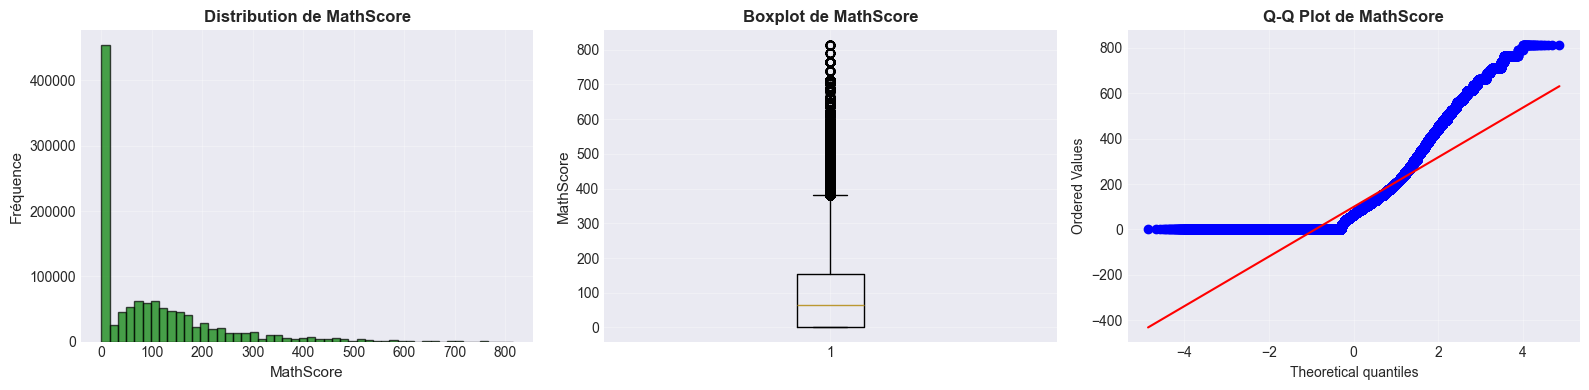

In [15]:
# Analyse de la variable cible (y_train)
if y_train is not None:
    print("="*80)
    print("🎯 ANALYSE DE LA VARIABLE CIBLE")
    print("="*80)
    
    # Si y_train a plusieurs colonnes, analyser la première ou toutes
    target_cols = y_train.columns
    print(f"Colonnes dans y_train: {list(target_cols)}\n")
    
    for target_col in target_cols[:3]:  # Analyser les 3 premières colonnes max
        print(f"\n{'='*80}")
        print(f"📊 Analyse de: {target_col}")
        print('='*80)
        
        target = y_train[target_col]
        
        # Statistiques descriptives
        print(f"\nNombre de valeurs: {len(target)}")
        print(f"Valeurs manquantes: {target.isnull().sum()} ({(target.isnull().sum()/len(target)*100):.2f}%)")
        print(f"Valeurs uniques: {target.nunique()}")
        
        # Vérifier si c'est numérique ou catégoriel
        if pd.api.types.is_numeric_dtype(target):
            print(f"\n📈 Statistiques descriptives:")
            print(target.describe())
            
            # Visualisation
            fig, axes = plt.subplots(1, 3, figsize=(16, 4))
            
            # Histogramme
            axes[0].hist(target.dropna(), bins=50, edgecolor='black', alpha=0.7, color='green')
            axes[0].set_xlabel(target_col, fontsize=11)
            axes[0].set_ylabel('Fréquence', fontsize=11)
            axes[0].set_title(f'Distribution de {target_col}', fontsize=12, fontweight='bold')
            axes[0].grid(alpha=0.3)
            
            # Boxplot
            axes[1].boxplot(target.dropna(), vert=True)
            axes[1].set_ylabel(target_col, fontsize=11)
            axes[1].set_title(f'Boxplot de {target_col}', fontsize=12, fontweight='bold')
            axes[1].grid(alpha=0.3)
            
            # QQ-plot (distribution normale)
            from scipy import stats
            stats.probplot(target.dropna(), dist="norm", plot=axes[2])
            axes[2].set_title(f'Q-Q Plot de {target_col}', fontsize=12, fontweight='bold')
            axes[2].grid(alpha=0.3)
            
            plt.tight_layout()
            plt.show()
        else:
            print(f"\n🏷️ Distribution des catégories:")
            print(target.value_counts().head(10))
            
            # Visualisation pour variables catégorielles
            value_counts = target.value_counts().head(10)
            plt.figure(figsize=(10, 6))
            plt.bar(range(len(value_counts)), value_counts.values, color='purple', edgecolor='black')
            plt.xticks(range(len(value_counts)), value_counts.index, rotation=45, ha='right')
            plt.xlabel('Catégorie', fontsize=11)
            plt.ylabel('Fréquence', fontsize=11)
            plt.title(f'Distribution de {target_col}', fontsize=13, fontweight='bold')
            plt.grid(axis='y', alpha=0.3)
            plt.tight_layout()
            plt.show()
else:
    print("⚠ y_train n'a pas été chargé")

## 1️⃣1️⃣ Rapport de Qualité des Données et Recommandations

In [16]:
# Génération du rapport de qualité des données
if X_train is not None:
    print("="*80)
    print("📋 RAPPORT DE QUALITÉ DES DONNÉES ET RECOMMANDATIONS")
    print("="*80)
    
    # 1. Colonnes à supprimer (>50% manquant)
    cols_to_drop = column_info[column_info['Pct_Manquant'] > 50]['Colonne'].tolist()
    print(f"\n🔴 COLONNES À SUPPRIMER (>50% de valeurs manquantes): {len(cols_to_drop)}")
    if len(cols_to_drop) > 0:
        print(f"   Exemples: {cols_to_drop[:10]}")
    
    # 2. Colonnes nécessitant une imputation (10-50% manquant)
    cols_to_impute = column_info[(column_info['Pct_Manquant'] >= 10) & 
                                  (column_info['Pct_Manquant'] <= 50)]['Colonne'].tolist()
    print(f"\n⚠️  COLONNES NÉCESSITANT UNE IMPUTATION (10-50% manquant): {len(cols_to_impute)}")
    if len(cols_to_impute) > 0:
        print(f"   Exemples: {cols_to_impute[:10]}")
    
    # 3. Colonnes de bonne qualité (<10% manquant)
    good_quality_cols = column_info[column_info['Pct_Manquant'] < 10]['Colonne'].tolist()
    print(f"\n✅ COLONNES DE BONNE QUALITÉ (<10% manquant): {len(good_quality_cols)}")
    
    # 4. Colonnes avec faible variance (potentiellement inutiles)
    low_variance_cols = []
    for col in numeric_cols:
        if X_train[col].std() < 0.01:
            low_variance_cols.append(col)
    
    print(f"\n⚡ COLONNES À FAIBLE VARIANCE (potentiellement inutiles): {len(low_variance_cols)}")
    if len(low_variance_cols) > 0:
        print(f"   Exemples: {low_variance_cols[:10]}")
    
    # 5. Recommandations pour la conversion de types
    object_to_numeric = []
    for col in X_train.select_dtypes(include='object').columns:
        try:
            pd.to_numeric(X_train[col])
            object_to_numeric.append(col)
        except:
            pass
    
    print(f"\n🔄 COLONNES 'OBJECT' CONVERTIBLES EN NUMÉRIQUE: {len(object_to_numeric)}")
    if len(object_to_numeric) > 0:
        print(f"   Exemples: {object_to_numeric[:10]}")
    
    # 6. Résumé des recommandations
    print("\n" + "="*80)
    print("💡 RÉSUMÉ DES RECOMMANDATIONS POUR LE PREPROCESSING")
    print("="*80)
    print(f"""
    1️⃣ Supprimer {len(cols_to_drop)} colonnes avec >50% de valeurs manquantes
    2️⃣ Impluter {len(cols_to_impute)} colonnes avec 10-50% de valeurs manquantes
       → Stratégie recommandée: médiane (numérique), mode (catégoriel)
    3️⃣ Remplacer les codes PISA (9999, 999, 99, 'r', 'n') par NaN avant imputation
    4️⃣ Considérer la suppression des {len(low_variance_cols)} colonnes à faible variance
    5️⃣ Convertir {len(object_to_numeric)} colonnes 'object' en numérique
    6️⃣ Standardiser les {len(numeric_cols)} variables numériques (StandardScaler)
    7️⃣ Encoder les {len(categorical_cols)} variables catégorielles (OneHotEncoder)
    8️⃣ Vérifier les corrélations fortes pour éviter la multicolinéarité
    """)

📋 RAPPORT DE QUALITÉ DES DONNÉES ET RECOMMANDATIONS

🔴 COLONNES À SUPPRIMER (>50% de valeurs manquantes): 206
   Exemples: ['science_q19_total_timing', 'math_q21_average_score', 'reading_q13_total_timing', 'science_q19_average_score', 'science_q18_average_score', 'science_q17_average_score', 'science_q15_average_score', 'science_q14_average_score', 'science_q13_average_score', 'math_q20_average_score']

⚠️  COLONNES NÉCESSITANT UNE IMPUTATION (10-50% manquant): 82
   Exemples: ['science_q7_total_timing', 'math_q9_total_timing', 'science_q8_average_score', 'reading_q6_total_timing', 'math_q9_average_score', 'math_q8_total_timing', 'science_q6_total_timing', 'reading_q5_total_timing', 'science_q5_total_timing', 'math_q7_total_timing']

✅ COLONNES DE BONNE QUALITÉ (<10% manquant): 19

⚡ COLONNES À FAIBLE VARIANCE (potentiellement inutiles): 0

🔄 COLONNES 'OBJECT' CONVERTIBLES EN NUMÉRIQUE: 0

💡 RÉSUMÉ DES RECOMMANDATIONS POUR LE PREPROCESSING

    1️⃣ Supprimer 206 colonnes avec >50% de v

In [18]:
# Export du rapport de qualité vers un fichier CSV
if X_train is not None:
    try:
        # Sauvegarde du tableau récapitulatif des colonnes
        column_info.to_csv('rapport/rapport_qualite_colonnes.csv', index=False, encoding='utf-8')
        print("\n" + "="*80)
        print("💾 EXPORT DES RÉSULTATS")
        print("="*80)
        print("✅ Rapport de qualité exporté vers: rapport_qualite_colonnes.csv")
        
        # Création d'un rapport synthétique
        synthese = {
            'Métrique': [
                'Total Colonnes',
                'Total Lignes',
                'Variables Numériques',
                'Variables Catégorielles',
                'Colonnes Complètes (0% manquant)',
                'Colonnes à Supprimer (>50% manquant)',
                'Colonnes à Imputer (10-50% manquant)',
                'Taux Moyen de Remplissage (%)',
                'Utilisation Mémoire (MB)'
            ],
            'Valeur': [
                len(X_train.columns),
                len(X_train),
                len(numeric_cols),
                len(categorical_cols),
                (column_info['Pct_Manquant'] == 0).sum(),
                len(cols_to_drop),
                len(cols_to_impute),
                column_info['Pct_Remplissage'].mean().round(2),
                (X_train.memory_usage(deep=True).sum() / 1024**2).round(2)
            ]
        }
        
        synthese_df = pd.DataFrame(synthese)
        synthese_df.to_csv('rapport/rapport_synthese.csv', index=False, encoding='utf-8')
        print("✅ Rapport de synthèse exporté vers: rapport_synthese.csv")
        
        print("\n📊 Aperçu du rapport de synthèse:")
        display(synthese_df)
        
    except Exception as e:
        print(f"❌ Erreur lors de l'export: {e}")


💾 EXPORT DES RÉSULTATS
✅ Rapport de qualité exporté vers: rapport_qualite_colonnes.csv
✅ Rapport de synthèse exporté vers: rapport_synthese.csv

📊 Aperçu du rapport de synthèse:
✅ Rapport de synthèse exporté vers: rapport_synthese.csv

📊 Aperçu du rapport de synthèse:


,Métrique,Valeur
0,Total Colonnes,307.00
1,Total Lignes,1172086.00
2,Variables Numériques,304.00
3,Variables Catégorielles,3.00
4,Colonnes Complètes (0% manquant),15.00
5,Colonnes à Supprimer (>50% manquant),206.00
6,Colonnes à Imputer (10-50% manquant),82.00
7,Taux Moyen de Remplissage (%),40.74
8,Utilisation Mémoire (MB),2897.63


---

## 🎓 Conclusion de l'Analyse Exploratoire

Cette analyse complète des données PISA a permis de:

✅ **Comprendre la structure** du dataset (dimensions, types de variables)  
✅ **Identifier les problèmes de qualité** (valeurs manquantes, codes PISA spécifiques)  
✅ **Analyser les distributions** des variables numériques et catégorielles  
✅ **Détecter les corrélations** entre variables  
✅ **Générer des recommandations** pour le preprocessing et la modélisation

### 🚀 Prochaines Étapes Recommandées:

1. **Nettoyage des données** selon les recommandations (suppression, imputation)
2. **Feature Engineering** pour créer de nouvelles variables pertinentes
3. **Preprocessing Pipeline** avec StandardScaler et OneHotEncoder
4. **Modélisation ML** avec XGBoost ou Random Forest
5. **Analyse d'équité** pour vérifier les biais potentiels (genre, origine socio-économique)
6. **Explicabilité** avec SHAP pour comprendre les facteurs de réussite

---

**Équipe HI!CKATHON 2025** - HEC Paris & Institut Polytechnique de Paris